In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('encoded.csv')
df = df.dropna(subset=['p_7'])
df = df.sample(frac=1)
dftest = df.tail(1075)
df = df.head(1075)

In [2]:
clf = tree.DecisionTreeClassifier()

X = df[['p_1','p_2','p_3','p_5','p_9','p_10','p_11','p_12','p_13','p_16','p_17','p_18','p_19','p_20','p_21',
        'p_22','p_23','p_24','p_25','p_26','p_27','p_28','p_29','Pregunta_30']]
X_test = dftest[['Pregunta_1','Pregunta_2','Pregunta_3','Pregunta_5','Pregunta_9','Pregunta_10','Pregunta_11','Pregunta_12',
                 'Pregunta_13','Pregunta_16','Pregunta_17','Pregunta_18','Pregunta_19','Pregunta_20','Pregunta_21','Pregunta_22',
                 'Pregunta_23','Pregunta_24','Pregunta_25','Pregunta_26','Pregunta_27','Pregunta_28','Pregunta_29','Pregunta_30']]

Y = df['Pregunta_7'] == 1
Y_test = dftest['Pregunta_7'] == 1

clf = clf.fit(X, Y)
Y_pred_test = clf.predict(X_test)

In [3]:
clf = RandomForestClassifier(n_estimators = 500, n_jobs = -1, bootstrap = True)
clf.fit(X,Y)
Y_pred_test =  clf.predict(X_test)

# Indicar en porcentaje la importancia de cada variable utilizada 
importance = clf.feature_importances_

# n_estimators / max_features / n_jobs
# bootstrap (permite realizar muestreo con remplazo en los arboles, se activa con bootstrap=True)

In [4]:
importance

array([0.0073091 , 0.00448999, 0.0095899 , 0.00272235, 0.00824078,
       0.00516341, 0.11187003, 0.75210385, 0.00399374, 0.01915343,
       0.00922163, 0.00339438, 0.00647223, 0.00294861, 0.00888594,
       0.00849494, 0.00317431, 0.00760427, 0.00300668, 0.00627674,
       0.01588372])

In [5]:
X.columns[importance == max(importance)]

Index(['Pregunta_10'], dtype='object')

In [6]:
# Correlación lineal

np.corrcoef(df['Pregunta_14'],df['Pregunta_7'])

array([[1.        , 0.02758923],
       [0.02758923, 1.        ]])

In [7]:
from sklearn.ensemble import RandomForestRegressor

clf2 = RandomForestRegressor(n_estimators = 750, n_jobs = -1).fit(X,Y)
importance2 = clf2.feature_importances_

In [8]:
importance2

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [9]:
np.mean(Y_test == Y_pred_test)

1.0

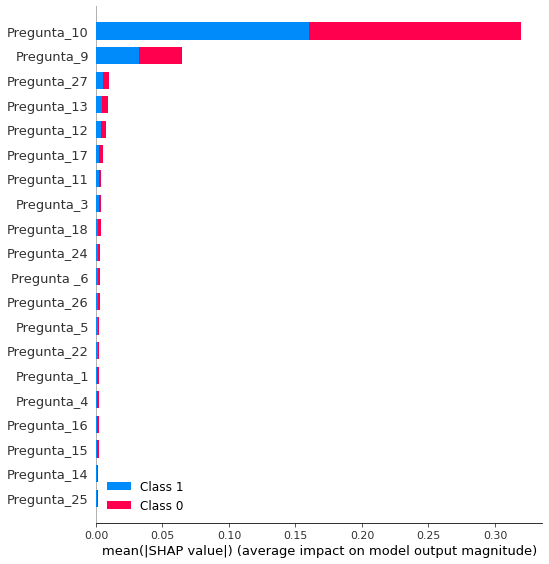

In [10]:
import shap

# summarize the effects of all the features
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

In [19]:
#shap.force_plot(explainer.expected_value, shap_values, X)

In [13]:
import eli5

eli5.show_weights(clf)

The sklearn.metrics.scorer module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.metrics. Anything that cannot be imported from sklearn.metrics is now part of the private API.
The sklearn.feature_selection.base module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.feature_selection. Anything that cannot be imported from sklearn.feature_selection is now part of the private API.


Weight,Feature
0.7521 ± 0.3793,x7
0.1119 ± 0.2062,x6
0.0192 ± 0.0421,x9
0.0159 ± 0.0373,x20
0.0096 ± 0.0250,x2
0.0092 ± 0.0239,x10
0.0089 ± 0.0218,x14
0.0085 ± 0.0220,x15
0.0082 ± 0.0212,x4
0.0076 ± 0.0218,x17
